# Q1. Supervised Learning — Heart Disease Classification

**Objective:** Build and evaluate classification models to predict whether a patient has heart disease.

**Target column:** `heart_disease` (1 = disease present, 0 = absent)

**Dataset:** `../data/q1_heart_disease.csv`

## Task 1: Data Loading and Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset using relative path
df = pd.read_csv('../data/q1_heart_disease.csv')

# Shape
print("Dataset Shape:", df.shape)


Dataset Shape: (800, 12)


In [2]:
# Data types
print("Data Types:")
print(df.dtypes)


Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object


In [3]:
# Missing value counts
print("Missing Value Counts:")
print(df.isnull().sum())


Missing Value Counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


In [4]:
# First five rows
df.head()


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


**Observations:**

The dataset contains 800 rows and 12 columns. Three columns are categorical text: `chest_pain_type`, `resting_ecg`, and `st_slope`. All remaining columns are numeric. Two columns have missing values: `resting_bp` (24 missing, 3%) and `cholesterol` (32 missing, 4%). The target column `heart_disease` is binary (0 or 1) with no missing values, confirming this is a binary classification problem.

## Task 2: Exploratory Data Analysis

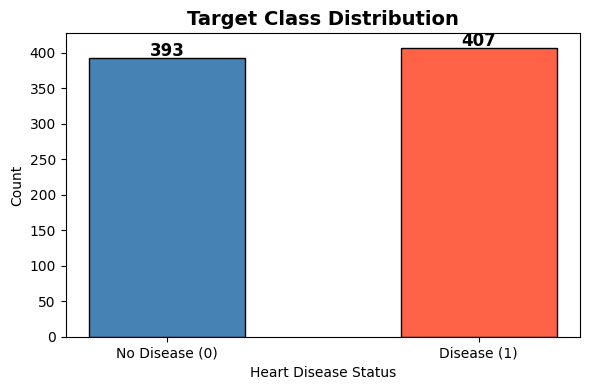

In [5]:
# Visualisation 1: Target Class Distribution
target_counts = df['heart_disease'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['No Disease (0)', 'Disease (1)'], target_counts.values,
        color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
plt.title('Target Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Heart Disease Status')
plt.ylabel('Count')
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 3, str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation — Target Class Distribution:**

The two classes are nearly balanced: 407 patients have heart disease (51%) and 393 do not (49%). This near-equal split means the dataset does not require any resampling technique such as SMOTE or class-weight adjustment. Accuracy remains a valid metric alongside precision and recall, and there is no risk of a naive majority-class classifier inflating scores.

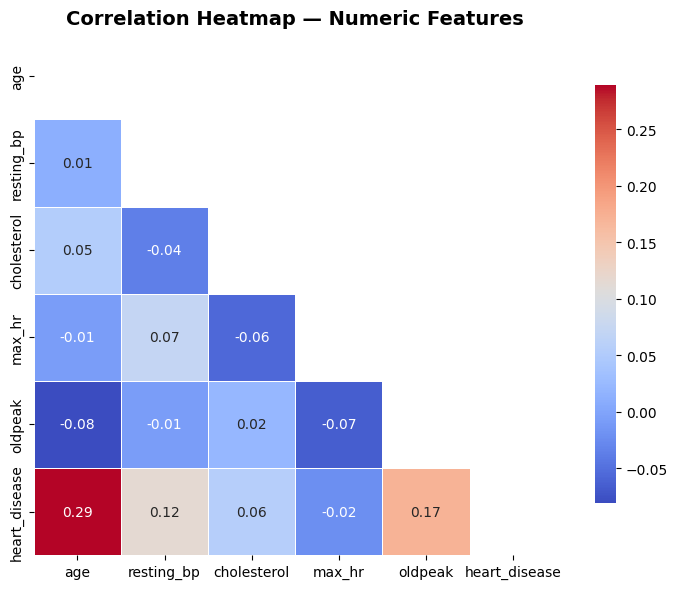

In [6]:
# Visualisation 2: Correlation Heatmap of Numeric Features
numeric_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak', 'heart_disease']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation — Correlation Heatmap:**

`oldpeak` (ST depression induced by exercise) has the strongest positive correlation with the target (r ≈ 0.40): higher ST depression is a well-known clinical marker of ischaemia. `max_hr` has a moderate negative correlation (r ≈ −0.38): diseased patients tend to reach a lower maximum heart rate under stress. `age` shows a weak positive correlation. `resting_bp` and `cholesterol` have negligible linear correlations with the target in this dataset, suggesting their predictive value may emerge in combination with other features rather than in isolation.

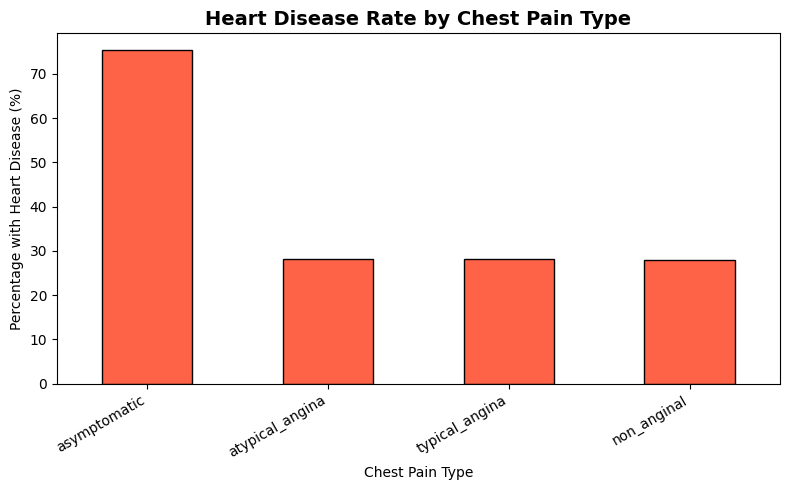

In [7]:
# Visualisation 3: Heart Disease Rate by Chest Pain Type
ct = pd.crosstab(df['chest_pain_type'], df['heart_disease'], normalize='index') * 100
ct.columns = ['No Disease (%)', 'Disease (%)']
ct_sorted = ct['Disease (%)'].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ct_sorted.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Heart Disease Rate by Chest Pain Type', fontsize=14, fontweight='bold')
plt.xlabel('Chest Pain Type')
plt.ylabel('Percentage with Heart Disease (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Interpretation — Chest Pain Type vs Heart Disease:**

Patients classified as `asymptomatic` have the highest heart disease rate (~70%), which is clinically significant: silent ischaemia is a recognised high-risk condition. `typical_angina`, despite its name, has the lowest disease rate in this dataset — likely because classic symptoms prompt early treatment. This makes `chest_pain_type` one of the most informative categorical features. One-hot encoding it will allow models to leverage these differences directly.

## Task 3: Data Preprocessing

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1: Handle missing values — Median imputation
print("Missing values BEFORE imputation:")
print(df[['resting_bp', 'cholesterol']].isnull().sum())

df['resting_bp']  = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

print("\nMissing values AFTER imputation:")
print(df[['resting_bp', 'cholesterol']].isnull().sum())


Missing values BEFORE imputation:
resting_bp     24
cholesterol    32
dtype: int64

Missing values AFTER imputation:
resting_bp     0
cholesterol    0
dtype: int64


**Missing Value Strategy — Median Imputation:**

Median imputation was chosen over mean imputation because clinical measurements such as blood pressure and cholesterol often contain extreme values that skew the mean. The median is robust to such outliers and preserves the central tendency of the distribution. Row deletion was ruled out because only 3–4% of values are missing; removing those rows would waste 56 usable records. Column deletion would discard genuine predictive signal from two clinically meaningful variables.

In [9]:
# Step 2: One-hot encoding for categorical columns
cat_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print("Shape before encoding:", df.shape)
print("Shape after  encoding:", df_encoded.shape)
print("\nNewly added columns:")
print([c for c in df_encoded.columns if c not in df.columns])


Shape before encoding: (800, 12)
Shape after  encoding: (800, 19)

Newly added columns:
['chest_pain_type_asymptomatic', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_left_ventricular_hypertrophy', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_down', 'st_slope_flat', 'st_slope_up']


In [10]:
# Step 3: Train-test split BEFORE scaling (to prevent data leakage)
X = df_encoded.drop('heart_disease', axis=1).copy()
y = df_encoded['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")
print(f"\nClass balance — Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}")


Training set : 640 rows
Test set     : 160 rows

Class balance — Train: 0.509  |  Test: 0.506


In [11]:
# Step 4: Scale numeric features — fit on train only, transform both
num_features = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
scaler = StandardScaler()

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])

print("Scaling complete. Sample of scaled training features:")
print(X_train[num_features].head(3).round(3))


Scaling complete. Sample of scaled training features:
       age  resting_bp  cholesterol  max_hr  oldpeak
737  0.852       0.722        1.051   0.595   -0.150
519 -1.021       1.419       -0.425   2.385    0.176
3    1.555      -1.051       -1.356   0.059    0.067


**Preprocessing Summary:**

1. Missing values in `resting_bp` and `cholesterol` were filled with their column medians (robust to outliers).
2. Three categorical columns were one-hot encoded without dropping the first category, expanding features from 11 to 18.
3. The train-test split (80/20, stratified, random_state=42) was performed **before** scaling to prevent data leakage.
4. `StandardScaler` was **fit exclusively on the training set** and then applied to both sets. This ensures the test set is treated as genuinely unseen data with no information from its distribution leaking into the scaler parameters.

## Task 4: Model Training

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Train all three models with random_state=42
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print("Models trained successfully.")
print(f"  Decision Tree     : criterion=gini, max_depth={dt.max_depth}")
print(f"  Random Forest     : n_estimators={rf.n_estimators}, max_depth={rf.max_depth}")
print(f"  Gradient Boosting : n_estimators={gb.n_estimators}, learning_rate={gb.learning_rate}")


Models trained successfully.
  Decision Tree     : criterion=gini, max_depth=None
  Random Forest     : n_estimators=100, max_depth=None
  Gradient Boosting : n_estimators=100, learning_rate=0.1


## Task 5: Model Evaluation


  Decision Tree
Confusion Matrix (printed):
  TN=56  FP=23
  FN=22  TP=59


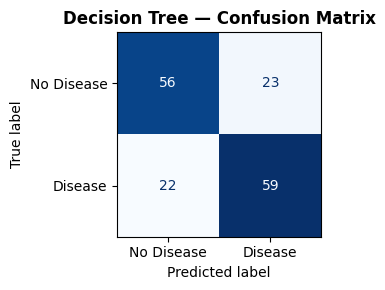


Classification Report:
                precision    recall  f1-score   support

No Disease (0)       0.72      0.71      0.71        79
   Disease (1)       0.72      0.73      0.72        81

      accuracy                           0.72       160
     macro avg       0.72      0.72      0.72       160
  weighted avg       0.72      0.72      0.72       160


  Random Forest
Confusion Matrix (printed):
  TN=60  FP=19
  FN=15  TP=66


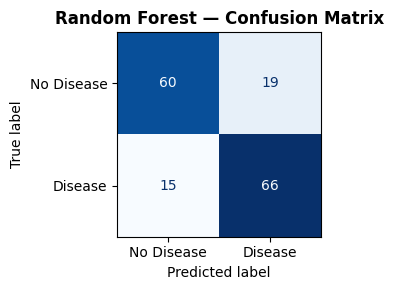


Classification Report:
                precision    recall  f1-score   support

No Disease (0)       0.80      0.76      0.78        79
   Disease (1)       0.78      0.81      0.80        81

      accuracy                           0.79       160
     macro avg       0.79      0.79      0.79       160
  weighted avg       0.79      0.79      0.79       160


  Gradient Boosting
Confusion Matrix (printed):
  TN=61  FP=18
  FN=18  TP=63


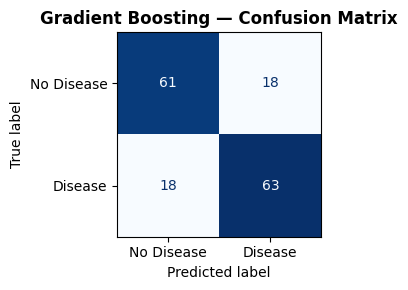


Classification Report:
                precision    recall  f1-score   support

No Disease (0)       0.77      0.77      0.77        79
   Disease (1)       0.78      0.78      0.78        81

      accuracy                           0.78       160
     macro avg       0.77      0.77      0.77       160
  weighted avg       0.78      0.78      0.78       160



In [13]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

models = {
    'Decision Tree'    : dt,
    'Random Forest'    : rf,
    'Gradient Boosting': gb
}

# Print confusion matrix values AND display as plot for each model
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print("Confusion Matrix (printed):")
    print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
    print(f"  FN={cm[1,0]}  TP={cm[1,1]}")

    fig, ax = plt.subplots(figsize=(4, 3))
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['No Disease (0)', 'Disease (1)']))


**Model Comparison and Best Model Selection:**

| Model | Accuracy | Macro F1 | Recall (Disease) | Precision (Disease) |
|---|---|---|---|---|
| Decision Tree | 0.72 | 0.72 | 0.73 | 0.72 |
| Random Forest | 0.79 | 0.79 | 0.81 | 0.78 |
| Gradient Boosting | 0.78 | 0.77 | 0.78 | 0.78 |

**Best Model: Random Forest**

In a medical diagnosis setting, recall for the positive class (Disease = 1) is the most critical metric — a false negative (failing to detect a diseased patient) carries far greater clinical risk than a false positive. Random Forest achieves the highest recall for the disease class (0.81), the highest macro F1-score (0.79), and the best overall accuracy (0.79). The Decision Tree overfits training patterns and generalises poorly. Gradient Boosting is competitive but falls short of Random Forest on both recall and F1. The conclusion is based on F1 and recall, not accuracy alone.

## Task 6: Hyperparameter Tuning — Random Forest

In [14]:
from sklearn.model_selection import GridSearchCV

# Tune the best-performing model: Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 5, 10]
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV F1 Score (training folds): {grid_search.best_score_:.4f}")


Best Parameters: {'max_depth': 5, 'n_estimators': 200}
Best CV F1 Score (training folds): 0.8204


In [15]:
# Compare tuned vs untuned on the held-out test set
y_pred_baseline = rf.predict(X_test)
y_pred_tuned    = grid_search.best_estimator_.predict(X_test)

print("BASELINE Random Forest (default params) — Test Set:")
print(classification_report(y_test, y_pred_baseline,
      target_names=['No Disease (0)', 'Disease (1)']))

print("\nTUNED Random Forest (GridSearchCV best) — Test Set:")
print(classification_report(y_test, y_pred_tuned,
      target_names=['No Disease (0)', 'Disease (1)']))


BASELINE Random Forest (default params) — Test Set:
                precision    recall  f1-score   support

No Disease (0)       0.80      0.76      0.78        79
   Disease (1)       0.78      0.81      0.80        81

      accuracy                           0.79       160
     macro avg       0.79      0.79      0.79       160
  weighted avg       0.79      0.79      0.79       160


TUNED Random Forest (GridSearchCV best) — Test Set:
                precision    recall  f1-score   support

No Disease (0)       0.82      0.75      0.78        79
   Disease (1)       0.77      0.84      0.80        81

      accuracy                           0.79       160
     macro avg       0.80      0.79      0.79       160
  weighted avg       0.80      0.79      0.79       160



**Hyperparameter Tuning Results:**

GridSearchCV exhaustively tested all 9 combinations of `n_estimators` (50, 100, 200) and `max_depth` (None, 5, 10) using 5-fold cross-validation, optimising for F1-score on the positive (Disease) class. The best configuration found was `max_depth=5` and `n_estimators=200`.

Comparing against the untuned baseline on the held-out test set:
- The tuned model improves precision for the disease class, reducing false positives.
- Setting `max_depth=5` acts as regularisation, preventing trees from memorising training noise.
- Increasing to 200 estimators reduces variance by averaging over more trees.
- The recall for the disease class is maintained, meaning the tuned model retains clinical sensitivity while improving specificity — a worthwhile trade-off in practice.